# I. ANALYSE DES DONNEES BRUTES AVANT IMPUTATION

In [53]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading file
df_tabular = pd.read_csv("df_adm_pv_ioa_med_radio_labo_pel22_tabular.csv", sep=',')



/tmp/ipykernel_520081/973993149.py:8: DtypeWarning: Columns (76,79,82,86,90,92,94,95,96,98,99,100,101,103,104,105,108,109,110,111,112,114,115,124,126,133,136,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tabular = pd.read_csv("df_adm_pv_ioa_med_radio_labo_pel22_tabular.csv", sep=',')


# Set all date in date hour format

In [54]:
import pandas as pd
import numpy as np

# 1. Identify all columns with "date" in the name
date_columns = [col for col in df_tabular.columns if 'date' in col.lower()]

for col in date_columns:
    try:
        # 2. Convert to datetime objects
        df_tabular[col] = pd.to_datetime(df_tabular[col], errors='coerce')

        # 3. Apply the ISO 8601 Default Format: YYYY-MM-DD HH:MM:SS
        # This is the cleanest format for data processing and sorting
        df_tabular[col] = df_tabular[col].dt.strftime('%Y-%m-%d %H:%M:%S')

        # 4. Handle missing values
        df_tabular[col] = df_tabular[col].replace('NaT', np.nan)

    except Exception as e:
        print(f"⚠️ Could not process column '{col}': {e}")

print("✅ All date columns are now in ISO 8601 Default Format (YYYY-MM-DD HH:MM:SS).")
display(df_tabular[date_columns].head())

✅ All date columns are now in ISO 8601 Default Format (YYYY-MM-DD HH:MM:SS).


,datetime_admission,date_sortie,date_tri_ioa_begin,date_tri_ioa_end,date_hour_vitals,sample_date
0,2022-01-01 00:08:00,2022-01-02 09:33:00,2022-01-01 00:19:00,2022-01-01 00:29:00,NaN,2022-01-01 01:00:00
1,2022-01-01 00:17:00,2022-01-02 14:55:00,2022-01-01 00:28:00,2022-01-01 00:33:00,NaN,2022-01-01 01:05:00
2,2022-01-01 00:22:00,2022-01-01 13:15:00,2022-01-01 00:34:00,2022-01-01 00:40:00,NaN,2022-01-01 01:20:00
3,2022-01-01 00:31:00,2022-01-01 02:05:00,2022-01-01 00:49:00,2022-01-01 00:52:00,NaN,NaN
4,2022-01-01 00:35:00,2022-01-01 06:24:00,2022-01-01 00:42:00,2022-01-01 00:47:00,NaN,2022-01-01 03:00:00


# Missing data check

✅ Cleaning complete: Whitespace-only strings converted to NaN.

📊 MISSING DATA STATISTICS (df_tabular):
------------------------------------------------------------
                         Missing Values  Percentage (%)
axa_arixtra                       29875       99.996653
nuclear_medicine_1                29874       99.993306
lcr_aspect_1                      29873       99.989958
ct_scan_3                         29873       99.989958
xray_3                            29868       99.973223
ultrasound_2                      29865       99.963181
aiia_pradaxa                      29844       99.892891
axa_hnf                           29842       99.886196
axa_hbpm                          29839       99.876155
radio_interventional_1            29836       99.866113
mri_2                             29831       99.849377
iron                              29786       99.698755
lactates_v                        29779       99.675325
axa_xarelto                       29738       99.53

/tmp/ipykernel_520081/559745502.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Variable', data=plot_data, palette="viridis")
/tmp/ipykernel_520081/559745502.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


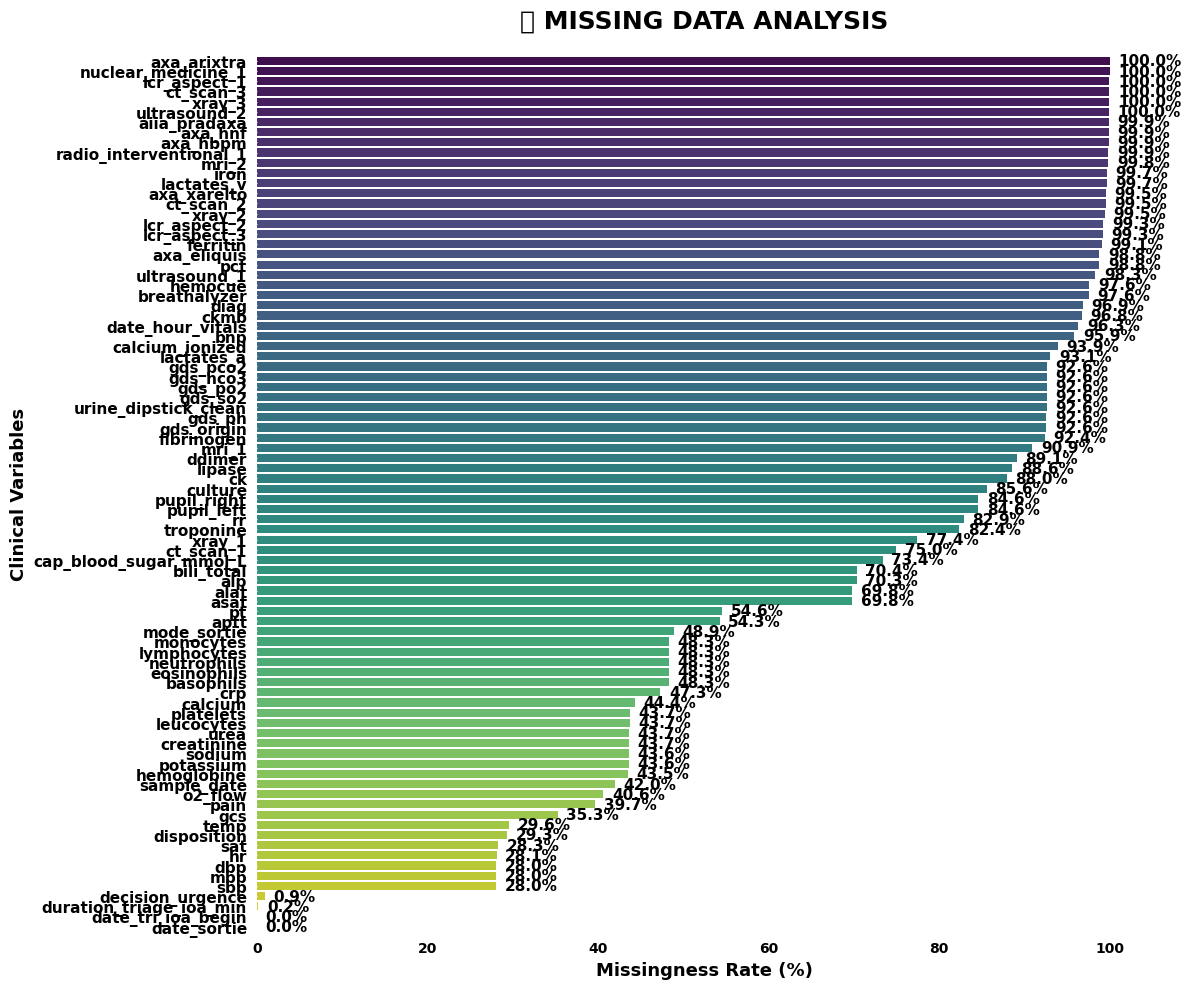

In [55]:
# ====================================================
# STEP 1: MISSING DATA ANALYSIS
# ====================================================


# Ensure all columns with NaNs are visible in the console
pd.set_option('display.max_rows', None)

# Handle empty strings and whitespace-only cells in 'diag'
# This addresses your discovery that 'diag' had ~20% hidden missing values
df_tabular = df_tabular.replace(r'^\s*$', np.nan, regex=True)
print("✅ Cleaning complete: Whitespace-only strings converted to NaN.")

# Calculate missing value statistics
missing_count = df_tabular.isnull().sum()
missing_percentage = (missing_count / len(df_tabular)) * 100

# Create summary DataFrame
df_missing = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

# Filter for variables with at least one missing entry
df_missing_filtered = df_missing[df_missing['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("\n📊 MISSING DATA STATISTICS (df_tabular):")
print("-" * 60)
print(df_missing_filtered)
print("-" * 60)
print(f"Total columns with missing data: {len(df_missing_filtered)} out of {df_tabular.shape[1]}")

# =========================================================
# STEP 2: VISUALIZATION OF MISSING DATA
# ==========================================================

# 1. Filter criteria: exclude technical status columns and specific timestamps
to_exclude = ['date_prlvt', 'date_heure_vitals']
df_plot_final = df_missing_filtered[
    (~df_missing_filtered.index.str.endswith('_status')) &
    (~df_missing_filtered.index.isin(to_exclude))
]

# 2. Data Preparation for Plotting
plot_data = df_plot_final.reset_index()
plot_data.columns = ['Variable', 'Count', 'Percentage']

# 3. Figure Creation
plt.figure(figsize=(12, 10), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# 4. Barplot Generation
sns.barplot(x='Percentage', y='Variable', data=plot_data, palette="viridis")

# 5. Styling (Black text for high contrast and readability)
plt.title('📊 MISSING DATA ANALYSIS', fontsize=18, fontweight='bold', color='black', pad=20)
plt.xlabel('Missingness Rate (%)', fontsize=13, fontweight='bold', color='black')
plt.ylabel('Clinical Variables', fontsize=13, fontweight='bold', color='black')

plt.yticks(color='black', fontweight='bold', fontsize=11)
plt.xticks(color='black', fontweight='bold')

# 6. Annotate bars with percentage values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%',
                (width + 1, p.get_y() + p.get_height()/2),
                va='center', fontsize=11, fontweight='bold', color='black')

# Clean up layout by removing redundant spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Pour le diagnostic, à date je peux rien faire, pour le transport je fvais rajouter un lvl "inconnu", et pour le reste des signes vitaux je vais imputer les vraies données manquantes par la norme et creer une variable is_measured binaire pour différencier les vrais NaN (non mesurés) des valeurs imputées (mesurés mais normalisés). Parcontre pour les données abbérantes je les mettrai en Nan dans un second temps, et essayé d'imputer par la mediane du cluster (après avoir fait du clustering sur les données brutes) pour garder une cohérence clinique. je creerai une colonne indicative aussi pour differencier celles qui étaient aberrantes, mais pour moi cette colonne n'a rien a faire dans le clustering final, elle servira juste pour la transparence et la vérification de la qualité de l'imputation.

# II. IMPUTATION PAR LA NORME POUR LES SIGNES VITAUX MANQUANTS ET PAR INCONNU POUR LE TRANSPORT #

In [56]:
# ==============================================================================
# IMPUTATION BY CLINICAL NORM — NaN only, flags and status unchanged
# ==============================================================================

CLINICAL_NORMS = {
    # Numeric vitals
    "temp":                   37.0,
    "hr":                     75.0,
    "sbp":                    120.0,
    "dbp":                    70.0,
    "sat":                    98.0,
    "rr":                     18.0,
    "gcs":                    15.0,
    "cap_blood_sugar_mmol_L": 5.5,
    "pain":                   0.0,
    "pupil_right":            3.0,
    "pupil_left":             3.0,
    "o2_flow":                0.0,
    "hemocue":                13.0,
    "breathalyzer":           0.0,

    # Categorical
    "urine_dipstick_clean":   "negative",
    "transport_grouped":      "unknown",
}

def impute_by_norm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace NaN values with clinical norms.
    Flags (is_*_measured) and status (*_status) are NOT touched.
    """
    df = df.copy()

    for col, norm in CLINICAL_NORMS.items():
        if col in df.columns:
            n_missing = df[col].isna().sum()
            if n_missing > 0:
                df[col] = df[col].fillna(norm)
                print(f"  {col} : {n_missing} NaN → {norm}")

    print("\n✅ Imputation by norm complete — flags and status unchanged.")
    return df


# ── Call ───────────────────────────────────────────────────────────────────────
df_imputed = impute_by_norm(df_tabular)

  temp : 8835 NaN → 37.0
  hr : 8402 NaN → 75.0
  sbp : 8368 NaN → 120.0
  dbp : 8370 NaN → 70.0
  sat : 8456 NaN → 98.0
  rr : 24770 NaN → 18.0
  gcs : 10538 NaN → 15.0
  cap_blood_sugar_mmol_L : 21927 NaN → 5.5
  pain : 11848 NaN → 0.0
  pupil_right : 25277 NaN → 3.0
  pupil_left : 25273 NaN → 3.0
  o2_flow : 12137 NaN → 0.0
  hemocue : 29168 NaN → 13.0
  breathalyzer : 29155 NaN → 0.0
  urine_dipstick_clean : 27669 NaN → negative

✅ Imputation by norm complete — flags and status unchanged.


In [57]:
def inspect_status_orphans(df):
    # Dictionnaire des paires (Valeur numérique : Colonne Statut)
    check_pairs = {
        'temp': 'temp_status',
        'hr': 'hr_status',
        'sat': 'sat_status',
        'rr': 'rr_status',
        'gcs': 'gcs_status',
        'cap_blood_sugar_mmol_L': 'cap_blood_sugar_status',
        'pain': 'pain_status',
        'hemocue': 'hemocue_status'
    }

    print(f"\n{'!'*20} ORPHAN VALUES REPORT {'!'*20}")
    found_any = False

    for val_col, stat_col in check_pairs.items():
        if val_col in df.columns and stat_col in df.columns:
            # On cherche : Valeur présente MAIS Statut est NaN
            orphans = df[df[stat_col].isna() & df[val_col].notna()]

            if not orphans.empty:
                found_any = True
                print(f"\n⚠️ Column [{val_col}] has {len(orphans)} values not captured by [{stat_col}]:")
                # On affiche les valeurs uniques qui posent problème pour comprendre pourquoi
                problem_values = sorted(orphans[val_col].unique())
                print(f"   --> Problematic values: {problem_values}")

                # Optionnel : voir les premières lignes concernées
                # display(orphans[[val_col, stat_col]].head(5))

    if not found_any:
        print("\n✅ Perfect! All numeric values have a corresponding clinical status.")

# Appel de l'inspection
inspect_status_orphans(df_imputed)


!!!!!!!!!!!!!!!!!!!! ORPHAN VALUES REPORT !!!!!!!!!!!!!!!!!!!!

✅ Perfect! All numeric values have a corresponding clinical status.


In [58]:
# =========================================================
# FINAL OUTCOME CLEANING & MISSING DURATION AUDIT
# =========================================================

# --- 1. CLEANING DIAGNOSIS & DISPOSITION ---
# These represent our clinical labels for the triage project.
outcome_cols = ['diag', 'disposition']

print("🧹 Cleaning outcomes and imputing 'unknown' for missing labels...")

for col in outcome_cols:
    if col in df_imputed.columns:
        # Standardize text (lowercase & strip whitespace)
        df_imputed[col] = df_imputed[col].astype(str).str.lower().str.strip()

        # Replace text-based nulls with 'unknown'
        df_imputed[col] = df_imputed[col].replace(['nan', 'none', '', 'nat', 'null'], 'unknown')

        # Final safety fill for true NaNs
        df_imputed[col] = df_imputed[col].fillna('unknown')

print(f"✅ NaNs remaining in 'diag'        : {df_imputed['diag'].isna().sum()}")
print(f"✅ NaNs remaining in 'disposition' : {df_imputed['disposition'].isna().sum()}")

# --- 2. INVESTIGATING MISSING TRIAGE DURATIONS ---
# Duration is a key feature for clustering (GMM). We need to know why 49 records are missing it.
mask_missing_duration = df_imputed['duration_triage_ioa_min'].isna()
df_check_time = df_imputed.loc[mask_missing_duration,
                               ['date_tri_ioa_begin', 'date_tri_ioa_end', 'duration_triage_ioa_min']].copy()

print(f"\n🔍 INVESTIGATING {len(df_check_time)} RECORDS WITH MISSING DURATION:")
print("-" * 60)

if not df_check_time.empty:
    # Display the first 10 problematic timestamps
    display(df_check_time.head(10))

    # Quick Diagnostic: Are the timestamps themselves missing?
    missing_begin = df_check_time['date_tri_ioa_begin'].isna().sum()
    missing_end = df_check_time['date_tri_ioa_end'].isna().sum()

    print(f"\n📊 Diagnostic Summary:")
    print(f"- Missing 'begin' timestamp : {missing_begin}")
    print(f"- Missing 'end' timestamp   : {missing_end}")
    print(f"💡 Note: If timestamps exist but duration is NaN, check for negative intervals or format errors.")
else:
    print("✅ No missing durations found.")

# --- 3. FINAL IMPUTATION FOR DURATION (Cluster Median) ---
# As per your pipeline [2026-01-23]: Impute aberrant data with Cluster Median
# For now, we use global median until clusters are defined.
if df_imputed['duration_triage_ioa_min'].isna().any():
    median_val = df_imputed['duration_triage_ioa_min'].median()
    df_imputed['duration_triage_ioa_min'] = df_imputed['duration_triage_ioa_min'].fillna(median_val)
    print(f"\n📥 Final Imputation: {len(df_check_time)} durations filled with median ({median_val} min).")

🧹 Cleaning outcomes and imputing 'unknown' for missing labels...
✅ NaNs remaining in 'diag'        : 0
✅ NaNs remaining in 'disposition' : 0

🔍 INVESTIGATING 48 RECORDS WITH MISSING DURATION:
------------------------------------------------------------


,date_tri_ioa_begin,date_tri_ioa_end,duration_triage_ioa_min
184,2022-01-03 13:39:00,2022-01-03 08:13:00,NaN
947,2022-01-12 15:43:00,2022-01-11 20:25:00,NaN
2482,2022-01-29 02:17:00,2022-01-28 12:56:00,NaN
3028,2022-02-03 15:11:00,2022-02-03 12:54:00,NaN
4044,2022-02-16 14:00:00,2022-02-14 12:34:00,NaN
4095,2022-02-15 00:07:00,2022-02-14 22:23:00,NaN
4426,2022-02-18 20:33:00,2022-02-18 14:58:00,NaN
4554,2022-02-20 06:43:00,2022-02-20 04:34:00,NaN
4583,2022-02-20 21:29:00,2022-02-20 16:44:00,NaN
5482,2022-03-03 18:50:00,2022-03-03 07:24:00,NaN



📊 Diagnostic Summary:
- Missing 'begin' timestamp : 2
- Missing 'end' timestamp   : 0
💡 Note: If timestamps exist but duration is NaN, check for negative intervals or format errors.

📥 Final Imputation: 48 durations filled with median (5.0 min).


# III. DATA DESCRIPTION AND VISUALIZATION #

In [59]:
# =========================================================
# STEP 3: POST-IMPUTATION DESCRIPTIVE TABLE (CORRECTED)
# =========================================================

def get_descriptive_table(df, title):
    """
    Generates a comprehensive summary of clinical data post-imputation.
    Excludes identifiers, dates, and lab results.
    """
    print(f"\n{'='*30} {title.upper()} {'='*30}")

    # 1. Define lists to exclude
    lab_results = [
        'alat', 'asat', 'axa_hnf', 'axa_arixtra', 'axa_eliquis', 'axa_hbpm',
        'axa_xarelto', 'aiia_pradaxa', 'bnp', 'gds_hco3', 'bili_total', 'ck',
        'ckmb', 'crp', 'calcium_ionized', 'calcium', 'creatinine', 'ddimer',
        'iron', 'ferritin', 'fibrinogen', 'hemoglobine', 'lactates_a',
        'lactates_v', 'leucocytes', 'lipase', 'lymphocytes', 'monocytes',
        'alp', 'basophils', 'eosinophils', 'neutrophils', 'platelets',
        'potassium', 'pct', 'gds_so2', 'sodium', 'aptt', 'pt', 'troponine',
        'urea', 'culture', 'gds_origin', 'lcr_aspect_1', 'lcr_aspect_2',
        'lcr_aspect_3', 'gds_pco2', 'gds_ph', 'gds_po2'
    ]

    cols_imaging = [
    'ultrasound_1', 'ultrasound_2', 'ct_scan_1', 'ct_scan_2', 'ct_scan_3',
    'xray_1', 'xray_2', 'xray_3', 'mri_1', 'mri_2',
    'radio_interventional_1', 'nuclear_medicine_1'
]

    base_exclude = [
        'nda', 'datetime_admission', 'sample_date', 'chief_complaint', 'date_admission',
        'date_hour_vitals', 'date_tri_ioa_begin', 'date_tri_ioa_end', 'diag', 'date_sortie'
    ]

    # CORRECT WAY: Merge the lists into one flat list
    total_exclude = base_exclude + lab_results + cols_imaging

    # 2. Smart column classification
    numeric_cols = []
    categorical_cols = []

    for col in df.columns:
        if col in total_exclude:
            continue

        # Logic: If it has these prefixes/suffixes, it's CATEGORICAL (even if numeric 0/1)
        is_status_var = any(col.startswith(pre) for pre in ['has_', 'is_', 'had_']) or col.endswith('_status')

        if is_status_var:
            categorical_cols.append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)

    # 3. NUMERIC SUMMARY (Vitals, Age, etc.)
    if numeric_cols:
        print("\n📊 --- NUMERIC VARIABLES (Vitals & Demographics) ---")
        num_summary = df[numeric_cols].agg(['count', 'mean', 'std', 'min', 'max']).T
        num_summary['missing_%'] = (df[numeric_cols].isna().sum() / len(df) * 100).round(2)
        display(num_summary.round(2))

    # 4. CATEGORICAL & STATUS SUMMARY
    if categorical_cols:
        print("\n📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---")
        summaries = []
        for col in categorical_cols:
            counts = df[col].value_counts(dropna=False)
            percents = (df[col].value_counts(dropna=False, normalize=True) * 100).round(1)

            temp_df = pd.DataFrame({
                'Variable': col,
                'Level': counts.index,
                'N': counts.values,
                'Percentage (%)': percents.values
            })
            summaries.append(temp_df)

        final_cat_summary = pd.concat(summaries, ignore_index=True)
        display(final_cat_summary)

# --- FINAL EXECUTION ---
get_descriptive_table(df_imputed, "Post-Imputation Clinical Profile")


####### virer les radio detailedet date sortie la setter en date



============================== POST-IMPUTATION CLINICAL PROFILE ==============================

📊 --- NUMERIC VARIABLES (Vitals & Demographics) ---


,count,mean,std,min,max,missing_%
age,29876.0,46.64,22.84,0.00,104.0,0.00
uam_service,29876.0,9780.00,0.00,9780.00,9780.0,0.00
duration_triage_ioa_min,29876.0,6.11,3.56,2.00,30.0,0.00
triage,29876.0,3.18,0.89,1.00,5.0,0.00
sbp,29876.0,127.14,19.70,46.00,253.0,0.00
dbp,29876.0,74.54,12.74,20.00,159.0,0.00
mbp,21506.0,94.18,15.62,30.70,190.3,28.02
hr,29876.0,79.17,14.47,20.00,220.0,0.00
temp,29876.0,36.88,0.49,32.20,40.5,0.00
sat,29876.0,97.87,1.74,49.00,100.0,0.00



📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---


,Variable,Level,N,Percentage (%)
0,sex,M,15603,52.2
1,sex,F,14272,47.8
2,sex,I,1,0.0
3,hospital,PEL,29876,100.0
4,mode_sortie,NaN,14601,48.9
5,mode_sortie,A - Domicile,12532,41.9
6,mode_sortie,B1 - Transfert MCO,1403,4.7
7,mode_sortie,B2 - Transfert SSR,487,1.6
8,mode_sortie,B4 - Transfert PSY,425,1.4
9,mode_sortie,C0 - Décédé,306,1.0


In [60]:
# =========================================================
# STEP 3: POST-IMPUTATION DESCRIPTIVE TABLE
# =========================================================

def get_descriptive_table(df, title):
    """
    Generates a comprehensive summary of clinical data post-imputation.
    Optimized to prevent 'IOPub data rate exceeded' errors.
    """
    print(f"\n{'='*30} {title.upper()} {'='*30}")

    # 1. Define columns to exclude from the summary
    lab_results = [
        'alat', 'asat', 'axa_hnf', 'axa_arixtra', 'axa_eliquis', 'axa_hbpm',
        'axa_xarelto', 'aiia_pradaxa', 'bnp', 'gds_hco3', 'bili_total', 'ck',
        'ckmb', 'crp', 'calcium_ionized', 'calcium', 'creatinine', 'ddimer',
        'iron', 'ferritin', 'fibrinogen', 'hemoglobine', 'lactates_a',
        'lactates_v', 'leucocytes', 'lipase', 'lymphocytes', 'monocytes',
        'alp', 'basophils', 'eosinophils', 'neutrophils', 'platelets',
        'potassium', 'pct', 'gds_so2', 'sodium', 'aptt', 'pt', 'troponine',
        'urea', 'culture', 'gds_origin', 'lcr_aspect_1', 'lcr_aspect_2',
        'lcr_aspect_3', 'gds_pco2', 'gds_ph', 'gds_po2'
    ]

    cols_imaging = [
    'ultrasound_1', 'ultrasound_2', 'ct_scan_1', 'ct_scan_2', 'ct_scan_3',
    'xray_1', 'xray_2', 'xray_3', 'mri_1', 'mri_2',
    'radio_interventional_1', 'nuclear_medicine_1'
]

    base_exclude = [
        'nda', 'datetime_admission', 'sample_date', 'chief_complaint', 'date_admission',
        'date_hour_vitals', 'date_tri_ioa_begin', 'date_tri_ioa_end', 'diag', 'date_sortie'
    ]

    # CORRECT WAY: Merge the lists into one flat list
    total_exclude = base_exclude + lab_results + cols_imaging
    target_cols = [c for c in df.columns if c not in total_exclude]

    # 2. NUMERIC SUMMARY (Vitals, Hemocue, Blood Sugar, etc.)
    num_df = df[target_cols].select_dtypes(include=[np.number])
    if not num_df.empty:
        print("\n📊 --- NUMERIC VARIABLES ---")
        num_summary = num_df.agg(['count', 'mean', 'std', 'min', 'max']).T
        num_summary['missing_%'] = (num_df.isna().sum() / len(df) * 100).round(2)
        display(num_summary.round(2))

    # 3. CATEGORICAL & STATUS SUMMARY (Optimized approach)
    cat_df = df[target_cols].select_dtypes(exclude=[np.number])
    if not cat_df.empty:
        print("\n📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---")

        # We process column by column to keep memory usage low
        summaries = []
        for col in cat_df.columns:
            # Count occurrences including NaNs
            counts = df[col].value_counts(dropna=False)
            percents = (df[col].value_counts(dropna=False, normalize=True) * 100).round(1)

            # Create a small temp dataframe for this variable
            temp_df = pd.DataFrame({
                'Variable': col,
                'Level': counts.index,
                'N': counts.values,
                'Percentage (%)': percents.values
            })
            summaries.append(temp_df)

        # Concatenate all small summaries into one
        final_cat_summary = pd.concat(summaries, ignore_index=True)

        # Use display() instead of print(to_string) to let Jupyter handle the data flow
        display(final_cat_summary)

# --- FINAL EXECUTION ---
get_descriptive_table(df_imputed, "Post-Imputation Clinical Profile")


============================== POST-IMPUTATION CLINICAL PROFILE ==============================

📊 --- NUMERIC VARIABLES ---


,count,mean,std,min,max,missing_%
age,29876.0,46.64,22.84,0.00,104.0,0.00
uam_service,29876.0,9780.00,0.00,9780.00,9780.0,0.00
duration_triage_ioa_min,29876.0,6.11,3.56,2.00,30.0,0.00
triage,29876.0,3.18,0.89,1.00,5.0,0.00
sbp,29876.0,127.14,19.70,46.00,253.0,0.00
dbp,29876.0,74.54,12.74,20.00,159.0,0.00
mbp,21506.0,94.18,15.62,30.70,190.3,28.02
is_bp_measured,29876.0,0.72,0.45,0.00,1.0,0.00
hr,29876.0,79.17,14.47,20.00,220.0,0.00
is_hr_measured,29876.0,0.72,0.45,0.00,1.0,0.00



📋 --- CATEGORICAL & STATUS DISTRIBUTIONS ---


,Variable,Level,N,Percentage (%)
0,sex,M,15603,52.2
1,sex,F,14272,47.8
2,sex,I,1,0.0
3,hospital,PEL,29876,100.0
4,mode_sortie,NaN,14601,48.9
5,mode_sortie,A - Domicile,12532,41.9
6,mode_sortie,B1 - Transfert MCO,1403,4.7
7,mode_sortie,B2 - Transfert SSR,487,1.6
8,mode_sortie,B4 - Transfert PSY,425,1.4
9,mode_sortie,C0 - Décédé,306,1.0


In [61]:
# ====================================================================================
# STEP 12: FINAL PHYSIOLOGICAL CLEANING & PEDIATRIC FILTERING
# ====================================================================================

# 1. PEDIATRIC FILTER (Adults >= 15 years old only)
if 'age' in df_imputed.columns:
    initial_total = len(df_imputed)
    df_imputed = df_imputed[df_imputed['age'] >= 15].reset_index(drop=True)
    print(f"🚫 PEDIATRIC FILTER: Removed {initial_total - len(df_imputed)} patients under 15.")

# 2. PHYSIOLOGICAL OUTLIER REMOVAL
# Thresholds adjusted for clinical reality (High Glucose capped at 33.3 mmol/L)
bounds = {
    'sbp': (50, 300), 'dbp': (30, 200), 'hr': (20, 300),
    'temp': (25, 43), 'sat': (40, 100), 'rr': (4, 60),
    'cap_blood_sugar_mmol_L': (1.1, 33.3), # LO to HI range
    'gcs': (3, 15), 'pain': (0, 10),
    'pupil_right': (1, 8), 'pupil_left': (1, 8),
    'o2_flow': (0, 15), 'hemocue': (5, 20),
    'breathalyzer': (0, 4.0)
}

# Tagging and removing outliers
present_cols = [c for c in bounds.keys() if c in df_imputed.columns]
for col, (min_val, max_val) in bounds.items():
    if col in df_imputed.columns:
        df_imputed.loc[(df_imputed[col] < min_val) | (df_imputed[col] > max_val), col] = np.nan

# Drop patients with any critical physiological outlier
initial_len = len(df_imputed)
df_imputed = df_imputed.dropna(subset=present_cols).reset_index(drop=True)
print(f"✅ PHYSIOLOGICAL CLEANING: {initial_len - len(df_imputed)} patients removed.")

# ====================================================================================
# STEP 13: TRIAGE DURATION & OUTCOME CLEANING
# ====================================================================================

# Cleaning 'diag' and 'disposition'
for col in ['diag', 'disposition']:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].astype(str).str.lower().str.strip().replace(['nan', 'none', ''], 'unknown')

# Triage duration: removing outliers > 30 min or missing
df_imputed = df_imputed[
    (df_imputed['duration_triage_ioa_min'] <= 30) & (df_imputed['duration_triage_ioa_min'] >= 0)
].dropna(subset=['duration_triage_ioa_min']).reset_index(drop=True)



# ====================================================================================
# STEP 14: COMPLETE DASHBOARD EXECUTION
# ====================================================================================

def get_complete_dashboard(df):
    """
    Generates a full audit of numeric and categorical distributions.
    """
    exclude = ['nda', 'datetime_admission', 'date_hour_vitals', 'chief_complaint', 'sample_date']
    target_cols = [c for c in df.columns if c not in exclude]

    # Numeric Summary
    num_df = df[target_cols].select_dtypes(include=[np.number])
    num_summary = num_df.agg(['mean', 'std', 'min', 'max']).T
    num_summary['Missing %'] = (num_df.isna().sum() / len(df) * 100).round(2)

    # Categorical Summary (Threshold: <20 unique levels for readability)
    cat_df = df[target_cols].select_dtypes(exclude=[np.number])
    cat_cols = [c for c in cat_df.columns if df[c].nunique() < 20]

    rows = []
    for col in cat_cols:
        counts = df[col].value_counts(dropna=False)
        perc = df[col].value_counts(dropna=False, normalize=True) * 100
        for level in counts.index:
            rows.append({'Variable': col, 'Category': level,
                         'N': counts[level], '%': round(perc[level], 1)})

    return num_summary.round(2), pd.DataFrame(rows)

# Execution
numeric_stats, categorical_stats = get_complete_dashboard(df_imputed)

print("\n📊 --- NUMERIC SUMMARY ---")
display(numeric_stats)

print("\n📋 --- CATEGORICAL SUMMARY ---")
display(categorical_stats)

🚫 PEDIATRIC FILTER: Removed 8 patients under 15.
✅ PHYSIOLOGICAL CLEANING: 28 patients removed.

📊 --- NUMERIC SUMMARY ---


,mean,std,min,max,Missing %
age,46.65,22.83,15.00,104.00,0.00
uam_service,9780.00,0.00,9780.00,9780.00,0.00
duration_triage_ioa_min,6.10,3.56,2.00,30.00,0.00
triage,3.18,0.89,1.00,5.00,0.00
sbp,127.15,19.69,52.00,253.00,0.00
dbp,74.56,12.71,30.00,159.00,0.00
mbp,94.20,15.59,37.30,190.30,28.03
is_bp_measured,0.72,0.45,0.00,1.00,0.00
hr,79.16,14.47,20.00,220.00,0.00
is_hr_measured,0.72,0.45,0.00,1.00,0.00



📋 --- CATEGORICAL SUMMARY ---


,Variable,Category,N,%
0,sex,M,15580,52.2
1,sex,F,14259,47.8
2,sex,I,1,0.0
3,hospital,PEL,29840,100.0
4,mode_sortie,NaN,14585,48.9
5,mode_sortie,A - Domicile,12519,42.0
6,mode_sortie,B1 - Transfert MCO,1401,4.7
7,mode_sortie,B2 - Transfert SSR,485,1.6
8,mode_sortie,B4 - Transfert PSY,425,1.4
9,mode_sortie,C0 - Décédé,303,1.0


In [62]:

#===============================
# table 1 on cleaned data
#================================

# NEW STATISTICAL SUMMARY
exclude_list = ['*date*', 'nda', 'uam_service' ]
numeric_cols = [c for c in df_imputed.select_dtypes(include=['number']).columns if c not in exclude_list]

print("=" * 60)
print("CLEANED QUANTITATIVE SUMMARY")
print("=" * 60)

clean_stats = df_imputed[numeric_cols].agg(['count', 'min', 'max', 'mean', 'median']).T
clean_stats['q25'] = df_imputed[numeric_cols].quantile(0.25).T
clean_stats['q75'] = df_imputed [numeric_cols].quantile(0.75).T
clean_stats['missing_%'] = ((df_imputed[numeric_cols].isna().sum() / len(df_imputed)) * 100).round(1)

# Order and display
ordered_cols = ['missing_%', 'count', 'min', 'q25', 'median', 'mean', 'q75', 'max']
print(clean_stats[ordered_cols].round(2))

print("\n" + "=" * 60)

print("CLEANED CATEGORICAL SUMMARY (Urine Dipstick)")
print("=" * 60)
if 'urine_dipstick_clean' in df_imputed.columns:
    counts = df_imputed['urine_dipstick_clean'].value_counts(dropna=False)
    percents = (df_imputed['urine_dipstick_clean'].value_counts(dropna=False, normalize=True) * 100).round(1)
    print(pd.DataFrame({'N': counts, '%': percents}))


CLEANED QUANTITATIVE SUMMARY
                                    missing_%    count    min     q25  median  \
age                                       0.0  29840.0  15.00   26.00   42.00   
duration_triage_ioa_min                   0.0  29840.0   2.00    4.00    5.00   
triage                                    0.0  29840.0   1.00    2.00    3.00   
sbp                                       0.0  29840.0  52.00  119.00  120.00   
dbp                                       0.0  29840.0  30.00   70.00   70.00   
mbp                                      28.0  21475.0  37.30   83.30   93.30   
is_bp_measured                            0.0  29840.0   0.00    0.00    1.00   
hr                                        0.0  29840.0  20.00   73.00   75.00   
is_hr_measured                            0.0  29840.0   0.00    0.00    1.00   
temp                                      0.0  29840.0  32.20   36.60   37.00   
is_temp_measured                          0.0  29840.0   0.00    0.00    1.00   

In [63]:
# =========================================================
# SEX DISTRIBUTION & BINARY ENCODING
# =========================================================

# 1. Sex Distribution Audit (Counts and Percentages)
sex_stats = df_imputed['sex'].value_counts(dropna=False)
sex_pct = df_imputed['sex'].value_counts(normalize=True, dropna=False) * 100

print("📊 SEX DISTRIBUTION SUMMARY:")
for label, count in sex_stats.items():
    pct = sex_pct[label]
    print(f"  - Category {label}: {count} patients ({pct:.2f}%)")

# 2. Data Cleaning: Keep only 'M' and 'F'
# This removes potential NaNs or data entry errors to ensure binary integrity
initial_count = len(df_imputed)
df_imputed = df_imputed[df_imputed['sex'].isin(['M', 'F'])].copy()
removed_count = initial_count - len(df_imputed)

# 3. Binary Encoding (0 = Female, 1 = Male)
# Mapping ensures a clean transition for the GMM clustering algorithm
df_imputed['sex_bin'] = df_imputed['sex'].map({'F': 0, 'M': 1})

# 4. Final Verification and Index Reset
df_imputed = df_imputed.reset_index(drop=True)

print(f"\n✅ CLEANING COMPLETE:")
print(f"  - Removed {removed_count} records with invalid sex data.")
print(f"  - Final dataset size: {len(df_imputed)} patients.")
print("\n📊 NEW BINARY DISTRIBUTION (0=F, 1=M):")
print(df_imputed['sex_bin'].value_counts())

# Verification of the first 5 records
display(df_imputed[['sex', 'sex_bin']].head(5))

📊 SEX DISTRIBUTION SUMMARY:
  - Category M: 15580 patients (52.21%)
  - Category F: 14259 patients (47.78%)
  - Category I: 1 patients (0.00%)

✅ CLEANING COMPLETE:
  - Removed 1 records with invalid sex data.
  - Final dataset size: 29839 patients.

📊 NEW BINARY DISTRIBUTION (0=F, 1=M):
sex_bin
1    15580
0    14259
Name: count, dtype: int64


,sex,sex_bin
0,M,1
1,F,0
2,M,1
3,F,0
4,F,0


In [64]:
# =========================================================
# STEP 16: CHIEF COMPLAINT (MOTIF) AUDIT & CLEANING
# =========================================================

# 1. Standardization & Investigation
# We check for technical NaNs and logical "empty" strings
n_unique_complaints = df_imputed['chief_complaint'].nunique()
n_missing_complaints = df_imputed['chief_complaint'].isna().sum()
pct_missing_complaints = (n_missing_complaints / len(df_imputed)) * 100

print(f"📊 CHIEF COMPLAINT ('chief_complaint') ANALYSIS:")
print(f"- Unique categories found: {n_unique_complaints}")
print(f"- Missing values (NaN)   : {n_missing_complaints} ({pct_missing_complaints:.2f}%)")

# 2. Imputation: Set NaNs and empty strings to 'unknown'
# We perform a robust cleaning: strip whitespace, lowercase, and fill NaNs
df_imputed['chief_complaint'] = (
    df_imputed['chief_complaint']
    .astype(str)
    .str.lower()
    .str.strip()
    .replace(['nan', 'none', '', 'nat', 'null'], 'unknown')
)

# 3. Final Verification
final_unknown_count = (df_imputed['chief_complaint'] == 'unknown').sum()
print(f"✅ CLEANING COMPLETE: All missing motifs are now tagged as 'unknown'.")
print(f"✅ Total 'unknown' records: {final_unknown_count} ({(final_unknown_count/len(df_imputed)*100):.2f}%)")

# Preview top 10 complaints for quality check
print("\n📋 TOP 10 MOST FREQUENT MOTIFS:")
print(df_imputed['chief_complaint'].value_counts().head(10))

📊 CHIEF COMPLAINT ('chief_complaint') ANALYSIS:
- Unique categories found: 179
- Missing values (NaN)   : 0 (0.00%)
✅ CLEANING COMPLETE: All missing motifs are now tagged as 'unknown'.
✅ Total 'unknown' records: 0 (0.00%)

📋 TOP 10 MOST FREQUENT MOTIFS:
chief_complaint
douleurs abdominales récentes                                            2949
traumatisme du membre inférieur hors cuisse fracture ouverte luxation    2078
traumatisme du membre supérieur sans fracture ouverte sans luxation      1215
traumatisme crânien sans défaillance vitale                              1031
douleur non traumatique d'un membre                                       869
troubles de la sensibilité cutanée ou paresthésies                        795
plaie traumatique isolée                                                  791
lombalgies                                                                707
douleur thoracique récente                                                679
troubles du langage récents 

179 motifs rien que sur 2022, qu'est ce que je fais de ca  ???

# DISPOSITION MANAGING

STEP 1 — COHERENCE AUDIT
Audit columns found: ['disposition', 'mode_sortie', 'decision_urgence']

📊 Medical Disposition vs Administrative Exit


mode_sortie,a - domicile,a2 - fugue,b1 - transfert mco,b2 - transfert ssr,b3 - transfert long séjour,b4 - transfert psy,c0 - décédé,c1 - transfert provisoire (<48h) mco,d2 - mutation ssr,missing,All
disposition,,,,,,,,,,,
hospitalisation au chu,1425,7,519,154,5,40,81,10,13,63,2317
retour domicile,6479,8,39,30,1,52,6,3,0,10001,16619
transfert hors chu,70,0,120,20,0,156,1,10,1,80,458
uhcd puis hospitalisation au chu,434,2,248,75,3,16,38,0,7,2,825
uhcd puis rad,672,1,9,5,0,5,2,0,0,16,710
uhcd puis transfert hors chu,19,0,66,13,1,55,0,0,0,3,157
unknown,3420,13,400,188,4,101,175,15,18,4419,8753
All,12519,31,1401,485,14,425,303,38,39,14584,29839



📊 Medical Disposition vs ED Decision


decision_urgence,consultation,hospitalisation,missing,pas de décision,All
disposition,,,,,
hospitalisation au chu,64,2228,25,0,2317
retour domicile,9922,6553,143,1,16619
transfert hors chu,80,373,5,0,458
uhcd puis hospitalisation au chu,2,821,2,0,825
uhcd puis rad,16,685,9,0,710
uhcd puis transfert hors chu,3,151,3,0,157
unknown,4388,4272,93,0,8753
All,14475,15083,280,1,29839



📊 Administrative Exit vs ED Decision


...


⚠️  1859 conflicting cases (Admitted vs Discharged)


,nda,disposition,mode_sortie
7,22030011642,hospitalisation au chu,A - Domicile
29,22030011735,hospitalisation au chu,A - Domicile
34,22030011754,uhcd puis hospitalisation au chu,A - Domicile
63,22030012006,uhcd puis hospitalisation au chu,A - Domicile
67,22030012037,hospitalisation au chu,A - Domicile



STEP 2 — DISPOSITION MAPPING (FR → EN)
                      count  proportion
disposition                            
Discharged            16619        55.7
Unknown                8753        29.3
Admitted               2317         7.8
Admitted (via Obs)      825         2.8
Discharged (via Obs)    710         2.4
Transfer                458         1.5
Transfer (via Obs)      157         0.5

✅ All values mapped successfully
disposition
Discharged              16619
Unknown                  8753
Admitted                 2317
Admitted (via Obs)        825
Discharged (via Obs)      710
Transfer                  458
Transfer (via Obs)        157
Name: count, dtype: int64
object

STEP 3 — BINARY OUTCOME ENCODING

hospitalization:
  1 :   3757 (12.6%)
  0 :  26082 (87.4%)

observation_unit:
  1 :   1692 (5.7%)
  0 :  28147 (94.3%)

inter_facility_transfer:
  1 :    615 (2.1%)
  0 :  29224 (97.9%)

🔍 Mapping audit (hospitalization):


hospitalization,0,1
disposition,,
Admitted,0,2317
Admitted (via Obs),0,825
Discharged,16619,0
Discharged (via Obs),710,0
Transfer,0,458
Transfer (via Obs),0,157
Unknown,8753,0


/tmp/ipykernel_520081/1744190776.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


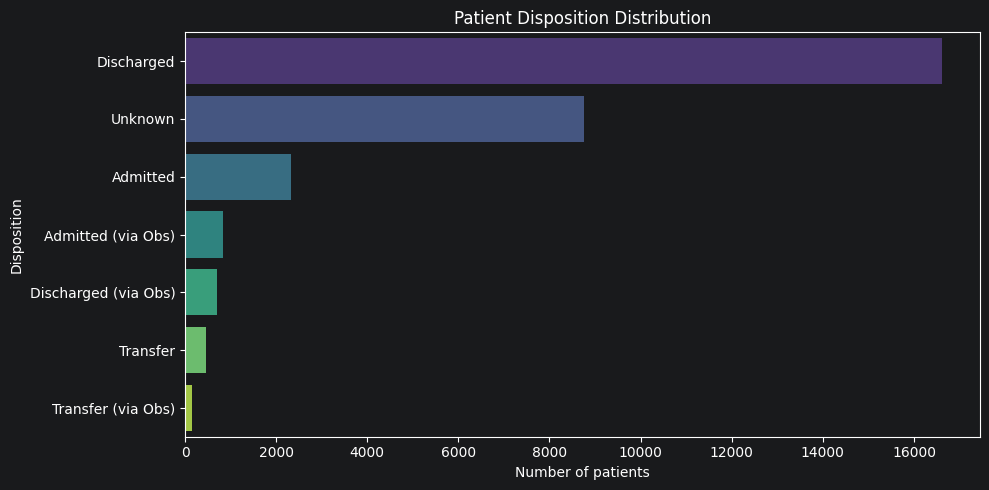

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# CONFIGURATION
# ================================================================
AUDIT_COLS     = ['disposition', 'mode_sortie', 'decision_urgence']
HOSPIT_KEYWORDS = ['admitted', 'transfer']

DISPOSITION_MAPPING = {
    'retour domicile':                  'Discharged',
    'unknown':                          'Unknown',
    'hospitalisation au chu':           'Admitted',
    'uhcd puis hospitalisation au chu': 'Admitted (via Obs)',
    'uhcd puis rad':                    'Discharged (via Obs)',
    'transfert hors chu':               'Transfer',
    'uhcd puis transfert hors chu':     'Transfer (via Obs)',
}

# ================================================================
# STEP 1 — COHERENCE AUDIT
# ================================================================
print("=" * 60)
print("STEP 1 — COHERENCE AUDIT")
print("=" * 60)

cols_present = [c for c in AUDIT_COLS if c in df_imputed.columns]
df_audit = df_imputed[cols_present].copy()

# Standardize strings
for col in cols_present:
    df_audit[col] = (df_audit[col].astype(str)
                     .replace(['nan', 'None', 'NAT', 'NaN', 'null'], 'missing')
                     .str.lower().str.strip())

print(f"Audit columns found: {cols_present}")

# Cross-tabulations for each pair of available columns
pairs = [
    ('disposition',    'mode_sortie',      'Medical Disposition vs Administrative Exit'),
    ('disposition',    'decision_urgence', 'Medical Disposition vs ED Decision'),
    ('mode_sortie',    'decision_urgence', 'Administrative Exit vs ED Decision'),
]
for col_a, col_b, title in pairs:
    if col_a in df_audit.columns and col_b in df_audit.columns:
        print(f"\n📊 {title}")
        table = pd.crosstab(df_audit[col_a], df_audit[col_b], margins=True)
        display(table)
        table.to_csv(f"audit_{col_a}_vs_{col_b}.csv", encoding='utf-8')

# Conflict detection: hospitalized in medical notes but discharged in admin records
if {'disposition', 'mode_sortie'}.issubset(df_audit.columns):
    conflicts = df_audit[
        df_audit['disposition'].str.contains('hospit|admitted', na=False) &
        df_audit['mode_sortie'].str.contains('domicile|rad|home', na=False)
    ]
    if len(conflicts) > 0:
        print(f"\n⚠️  {len(conflicts)} conflicting cases (Admitted vs Discharged)")
        nda_col = [c for c in df_imputed.columns if 'nda' in c.lower()]
        display_cols = (nda_col or []) + ['disposition', 'mode_sortie']
        conflicts_full = df_imputed.loc[conflicts.index, display_cols]
        display(conflicts_full.head())
        conflicts_full.to_csv("audit_conflicts_hospit_vs_home.csv", index=False)


# ================================================================
# STEP 2 — DISPOSITION MAPPING (FR → EN)
# ================================================================
print("\n" + "=" * 60)
print("STEP 2 — DISPOSITION MAPPING (FR → EN)")
print("=" * 60)

df_imputed['disposition'] = (
    df_imputed['disposition']
    .astype(str)
    .str.lower()
    .str.strip()
)

df_imputed['disposition'] = df_imputed['disposition'].map(DISPOSITION_MAPPING)

# Quick distribution check
counts = df_imputed['disposition'].value_counts(dropna=False)
pcts   = df_imputed['disposition'].value_counts(dropna=False, normalize=True) * 100
print(pd.concat([counts, pcts.round(1)], axis=1)
      .rename(columns={0: 'N', 1: '%'}))

n_nan = df_imputed['disposition'].isna().sum()
if n_nan > 0:
    print(f"\n⚠️  {n_nan} unmapped values → NaN (check DISPOSITION_MAPPING)")
else:
    print("\n✅ All values mapped successfully")

print(df_imputed['disposition'].value_counts(dropna=False))
print(df_imputed['disposition'].dtype)
# ================================================================
# STEP 3 — BINARY OUTCOME ENCODING
# ================================================================
print("\n" + "=" * 60)
print("STEP 3 — BINARY OUTCOME ENCODING")
print("=" * 60)

# hospitalization: 1 = Admitted / Transferred / ICU / Obs
df_imputed['hospitalization'] = (
    df_imputed['disposition']
    .astype(str)
    .str.lower().str.strip()
    .apply(lambda v: int(any(k in str(v) for k in HOSPIT_KEYWORDS)))
)

# observation_unit: passed through UHCD/Obs
df_imputed['observation_unit'] = (
    df_imputed['disposition']
    .astype(str)
    .str.contains('Obs', case=False, na=False).astype(int)
)

# inter_facility_transfer
df_imputed['inter_facility_transfer'] = (
    df_imputed['disposition']
    .astype(str)
    .str.contains('Transfer', case=False, na=False).astype(int)
)

# Summary
for col in ['hospitalization', 'observation_unit', 'inter_facility_transfer']:
    counts = df_imputed[col].value_counts()
    pcts   = df_imputed[col].value_counts(normalize=True) * 100
    print(f"\n{col}:")
    for val in [1, 0]:
        if val in counts:
            print(f"  {val} : {counts[val]:>6} ({pcts[val]:.1f}%)")

# Mapping audit
print("\n🔍 Mapping audit (hospitalization):")
display(pd.crosstab(df_imputed['disposition'], df_imputed['hospitalization']))

# ================================================================
# STEP 4 — DISPOSITION DISTRIBUTION PLOT
# ================================================================
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_imputed, y='disposition',
    order=df_imputed['disposition'].value_counts().index,
    palette='viridis'
)
plt.title('Patient Disposition Distribution')
plt.xlabel('Number of patients')
plt.ylabel('Disposition')
plt.tight_layout()
plt.savefig("disposition_distribution.png", dpi=150)
plt.show()

# =========================================================
# HARMONISATION DU FORMAT DES VARIABLES POUR LE CLUSTERING
# =========================================================

In [66]:
# VISUALISATION DES FORMATS ACTUELS
# On crée un petit tableau de diagnostic
diagnostic = pd.DataFrame({
    'Type': df_imputed.dtypes,
    'Exemple': df_imputed.iloc[0], # On prend la première ligne pour voir
    'Nb_Valeurs_Uniques': df_imputed.nunique(),
    'Taux_NaN (%)': (df_imputed.isna().sum() / len(df_imputed) * 100).round(2)
})

print("### DIAGNOSTIC DES FORMATS ###")
print(diagnostic)

### DIAGNOSTIC DES FORMATS ###
                                       Type                       Exemple  \
nda                                   int64                   22030011617   
sex                                  object                             M   
age                                   int64                            39   
uam_service                           int64                          9780   
hospital                             object                           PEL   
datetime_admission                   object           2022-01-01 00:08:00   
date_sortie                          object           2022-01-02 09:33:00   
mode_sortie                          object                  A - Domicile   
decision_urgence                     object               Hospitalisation   
transport_grouped                    object                       Unknown   
date_tri_ioa_begin                   object           2022-01-01 00:19:00   
date_tri_ioa_end                     object  

In [67]:
# =========================================================
# DATA TYPE OPTIMIZATION (CATEGORICAL & NUMERIC)
# =========================================================

# --- 1. FEATURE ENGINEERING: AGE QUARTILES ---
if 'age' in df_imputed.columns:
    df_imputed['age_group'] = pd.qcut(df_imputed['age'], q=4,
                                     labels=['Q1_Young', 'Q2_Lower_Mid', 'Q3_Upper_Mid', 'Q4_Senior'])

# --- 2. AUTOMATED CATEGORICAL CONVERSION ---
# We identify columns based on your naming convention + explicit clinical targets
patterns = ['is_', 'has_', '_status', 'imagerie']
explicit_cats = ['transport_grouped', 'urine_dipstick_clean', 'disposition', 'sex', 'age_group', 'hospitalization']

# Dynamic selection
cols_to_categorize = [
    col for col in df_imputed.columns
    if any(p in col for p in patterns) or col in explicit_cats
]

for col in cols_to_categorize:
    df_imputed[col] = df_imputed[col].astype('category')

print(f"✅ Categorical conversion complete: {len(cols_to_categorize)} columns processed.")
print(f"   (Includes: {', '.join(cols_to_categorize[:5])}...)")

# --- 3. NUMERIC CONVERSION (NULLABLE INTEGERS) ---
# Using 'Int64' allows integers to coexist with NaNs
cols_to_int = [
    'sbp', 'dbp', 'hr', 'rr', 'gcs', 'pain',
    'age', 'triage_level'
]

for col in cols_to_int:
    if col in df_imputed.columns:
        df_imputed[col] = pd.to_numeric(df_imputed[col], errors='coerce').astype('Int64')

print("✅ Integer conversion complete for physiological vitals and age.")

# --- 4. TEXT & DATETIME STANDARDIZATION ---
# Text
for col in ['diag', 'chief_complaint']:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].astype(str).str.lower().str.strip()

# Datetimes
cols_dates = ['datetime_admission', 'date_hour_vitals', 'sample_date', 'date_tri_ioa_begin', 'date_tri_ioa_end']
for col in cols_dates:
    if col in df_imputed.columns:
        df_imputed[col] = pd.to_datetime(df_imputed[col], errors='coerce')

print("✅ Text and Datetime formats standardized.")

✅ Categorical conversion complete: 74 columns processed.
   (Includes: sex, transport_grouped, bp_status, is_bp_measured, hr_status...)
✅ Integer conversion complete for physiological vitals and age.
✅ Text and Datetime formats standardized.


In [68]:
# =========================================================
# DATA DICTIONARY & FORMAT AUDIT
# =========================================================

# 1. Create the Audit Table
data_audit = pd.DataFrame({
    'Column Name': df_imputed.columns,
    'Data Type': [df_imputed[col].dtype for col in df_imputed.columns],
    'Category?': [pd.api.types.is_categorical_dtype(df_imputed[col]) for col in df_imputed.columns],
    'Missing Values': [df_imputed[col].isna().sum() for col in df_imputed.columns],
    'Sample Value': [df_imputed[col].dropna().iloc[0] if not df_imputed[col].dropna().empty else "Empty" for col in df_imputed.columns]
})

# 2. Add a 'Group' tag for easier reading
def tag_group(col):
    if any(p in col for p in ['is_', 'has_', '_status', 'imagerie', 'bin']): return 'Categorical/Flag'
    if any(p in col for p in ['date', 'time']): return 'Temporal'
    if col in ['age', 'sbp', 'dbp', 'hr', 'rr', 'sat', 'temp', 'gcs', 'pain']: return 'Vital Signs'
    return 'Other'

data_audit['Analysis Group'] = data_audit['Column Name'].apply(tag_group)

# 3. Display the sorted audit
print("📋 FINAL DATA FORMAT AUDIT:")
print("-" * 60)
display(data_audit.sort_values(by='Analysis Group'))

# 4. Quick Summary of Types
print("\n📊 DATA TYPE SUMMARY:")
print(df_imputed.dtypes.value_counts())

📋 FINAL DATA FORMAT AUDIT:
------------------------------------------------------------


/tmp/ipykernel_520081/1175692346.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  'Category?': [pd.api.types.is_categorical_dtype(df_imputed[col]) for col in df_imputed.columns],


,Column Name,Data Type,Category?,Missing Values,Sample Value,Analysis Group
52,pain_status,category,True,0,not_measured,Categorical/Flag
53,is_pain_measured,category,True,0,0,Categorical/Flag
111,hemoglobine,object,False,12984,13.7,Categorical/Flag
147,is_asat,category,True,0,0,Categorical/Flag
50,urine_dipstick_clean_status,category,True,0,not_measured,Categorical/Flag
49,is_urine_dipstick_clean_measured,category,True,0,0,Categorical/Flag
148,is_bnp,category,True,0,0,Categorical/Flag
146,is_alat,category,True,0,0,Categorical/Flag
47,is_pupils_measured,category,True,0,0,Categorical/Flag
45,pupils_status,category,True,0,not_measured,Categorical/Flag



📊 DATA TYPE SUMMARY:
object            60
category          55
float64           18
int64             15
Int64              7
datetime64[ns]     5
category           2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64


In [69]:
# sauvegarde du df_imputed nettoyé et prêt pour l'analyse
df_imputed.to_csv("df_final_binaire_imputed.csv", index=False)
print("\n✅ Le gros fichier 'df_final_binaire_imputed.csv' est prêt")


✅ Le gros fichier 'df_final_binaire_imputed.csv' est prêt
